# Problem Set 02 — Bank Marketing: Term Deposit Subscription Prediction (Logistic Regression)

**Task:** Predict whether a customer will subscribe to a term deposit (`yes`/`no`)
based on their demographic and banking behaviour data, using Logistic Regression.

**How to use this notebook in Google Colab:**
1. Runtime → Change runtime type → GPU is not required for this one (CPU is fine)
2. Run the cells top to bottom
3. Cell 1 downloads the dataset directly from the Google Drive share link — no manual upload needed

## 1. Download & Extract the Dataset

In [1]:
!pip install -q gdown
import gdown
import zipfile
import os

FILE_ID = '18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ'
OUTPUT_PATH = '/content/bank_data_download'

gdown.download(id=FILE_ID, output=OUTPUT_PATH, quiet=False)

# Detect if it's a zip or a direct csv, and handle accordingly
import shutil

if zipfile.is_zipfile(OUTPUT_PATH):
    EXTRACT_PATH = '/content/data'
    with zipfile.ZipFile(OUTPUT_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print('Extracted a zip file. Contents:')
    for root, dirs, files in os.walk(EXTRACT_PATH):
        for f in files:
            print(os.path.join(root, f))
else:
    # It's likely already a CSV, just rename with .csv extension for clarity
    CSV_PATH = '/content/bank.csv'
    shutil.copy(OUTPUT_PATH, CSV_PATH)
    print('Downloaded file appears to be a direct CSV. Saved as:', CSV_PATH)

Downloading...
From: https://drive.google.com/uc?id=18KwSR9aVTZRNaOVF76VE9USSEkqnYzzQ
To: /content/bank_data_download
100%|██████████| 516k/516k [00:00<00:00, 33.8MB/s]

Extracted a zip file. Contents:
/content/data/bank-data/bank-full.csv
/content/data/bank-data/.DS_Store
/content/data/__MACOSX/._bank-data
/content/data/__MACOSX/bank-data/._bank-full.csv
/content/data/__MACOSX/bank-data/._.DS_Store


## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

pd.set_option('display.max_columns', None)

## 3. Load the Data

**IMPORTANT:** After running cell 1, check what it printed. If it extracted a zip,
update `DATA_PATH` below to point to the actual `.csv` file found inside
(commonly named `bank.csv` or `bank-full.csv`). The UCI Bank Marketing dataset
is usually **semicolon-separated** (`sep=';'`) — if columns look wrong (e.g. only
1 column), try switching between `sep=';'` and `sep=','`.

In [4]:
DATA_PATH ='/content/data/bank-data/bank-full.csv'  # TODO: adjust based on what cell 1 printed

df = pd.read_csv(DATA_PATH, sep=';')

# If that produced only 1 column, uncomment the line below instead:
# df = pd.read_csv(DATA_PATH, sep=',')

print('Shape:', df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 4. Explore the Data

In [5]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nTarget column value counts:')
# The target column is usually named 'y' in this dataset
target_col = 'y' if 'y' in df.columns else df.columns[-1]
print(f"Using '{target_col}' as target column")
print(df[target_col].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values per column:
age          0
job          0
marital      0
education    0
default    

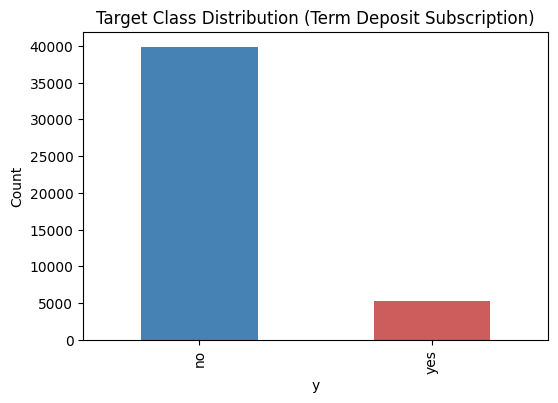

In [6]:
plt.figure(figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', color=['steelblue', 'indianred'])
plt.title('Target Class Distribution (Term Deposit Subscription)')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Preprocessing

- Encode the binary target column (`yes`/`no` → `1`/`0`)
- One-hot encode categorical features (job, marital, education, etc.)
- Scale numeric features (Logistic Regression is sensitive to feature scale)

In [7]:
df_clean = df.copy()

# Encode target: yes -> 1, no -> 0
df_clean[target_col] = df_clean[target_col].map({'yes': 1, 'no': 0})

# Identify categorical vs numeric columns
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print('\nFinal feature matrix shape:', X.shape)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Final feature matrix shape: (45211, 42)


## 6. Train/Test Split & Feature Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (36168, 42)
Test shape: (9043, 42)


## 7. Train the Logistic Regression Model

`class_weight='balanced'` is used because this dataset is typically imbalanced
(far more "no" than "yes" responses).

In [9]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

print('Model trained.')

Model trained.


## 8. Evaluate the Model

In [10]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Accuracy:  0.8460
Precision: 0.4186
Recall:    0.8138
F1-score:  0.5528
ROC-AUC:   0.9079

Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.85      0.91      7985
         yes       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



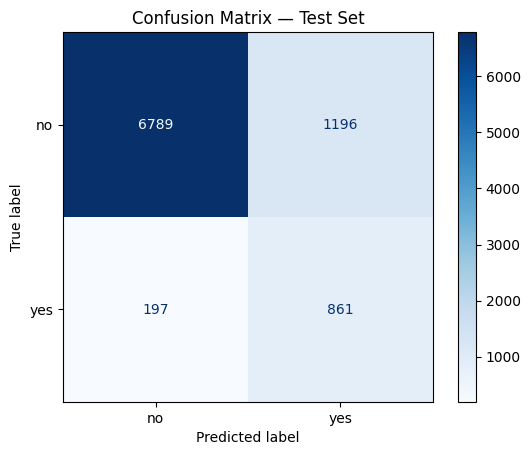

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

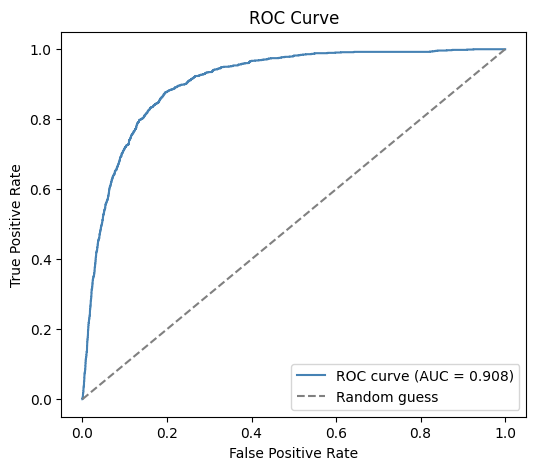

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})', color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance

Which features push a customer's prediction toward "yes" or "no"? Logistic
Regression coefficients tell us this directly.

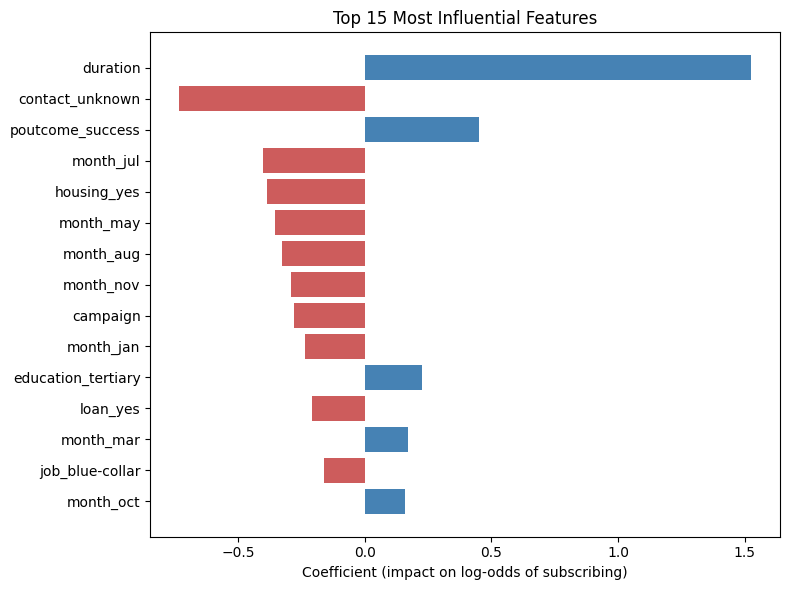

           feature  coefficient
          duration     1.526409
   contact_unknown    -0.733499
  poutcome_success     0.451346
         month_jul    -0.402798
       housing_yes    -0.384133
         month_may    -0.355000
         month_aug    -0.328285
         month_nov    -0.289399
          campaign    -0.278326
         month_jan    -0.234466
education_tertiary     0.226362
          loan_yes    -0.206612
         month_mar     0.171948
   job_blue-collar    -0.160333
         month_oct     0.158273


In [13]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

top_features = coef_df.head(15)

plt.figure(figsize=(8, 6))
colors = ['indianred' if c < 0 else 'steelblue' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.xlabel('Coefficient (impact on log-odds of subscribing)')
plt.title('Top 15 Most Influential Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(top_features.to_string(index=False))

## 10. Save the Model

In [14]:
import joblib
joblib.dump(model, 'bank_marketing_logreg_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model and scaler saved.')

Model and scaler saved.


In [15]:
from google.colab import files
files.download('class_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
files.download('roc_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
files.download('bank_marketing_logreg_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>